# Regression Modeling with Argo Data

This workbook introduces basic concepts behind training a machine learning regression model using Argo data. 

Our example application is to estimate a nitrate record along the trajectory of a glider from the California Underwater Glider Network, which provides measurements of temperature, salinity, and and oxygen at depths 0–500m in the California Current Upwelling System (e.g. [Ren et al. 2025](https://doi-org.offcampus.lib.washington.edu/10.1016/j.pocean.2025.103473)). 


Objectives: 
- Understand the importance of model cross-validation and its sensitivity to type of data splitting 
- Understand the difference between model parameters and hyperparameters
- Understand how to train a simple regressor (Random Forest) on Argo data using scikit-learn

Future references: 
- Online textbook from the UW course [Machine Learning in Geosciences (ESS659)](https://geo-smart.github.io/mlgeo-book/about_this_book/about_this_book.html)

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
from datetime import datetime

import matplotlib.pyplot as plt
from cmocean import cm as cmo
from cartopy import crs as ccrs

from scipy.stats import iqr
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Most of the custom functions live in a separate file `argotools.py` (open in another tab to follow along), which we import as the module `mod_argo`. 


In [2]:
import argotools as mod_argo

# for song: preload this

In [43]:
gliderDF.loc[pd.IndexSlice[0,:]]

mission_name  u_depth_mean  v_depth_mean  temperature  \
profile depth                                                         
47947   10     b'07401401'     -0.201391     -0.069573    13.738900   
        20     b'07401401'     -0.201391     -0.069573    13.738846   
        30     b'07401401'     -0.201391     -0.069573    13.699692   
        40     b'07401401'     -0.201391     -0.069573    13.478000   
        50     b'07401401'     -0.201391     -0.069573    12.842583   
...                    ...           ...           ...          ...   
51172   460    b'07401401'     -0.034017      0.037101     6.326875   
        470    b'07401401'     -0.034017      0.037101     6.277000   
        480    b'07401401'     -0.034017      0.037101     6.230000   
        490    b'07401401'     -0.034017      0.037101     6.158400   
        500    b'07401401'     -0.034017      0.037101     6.122222   

                salinity  chlorophyll_a         u         v  \
profile depth                                                 
47947   10     32.759000       0.684300 -0.184668  0.114028   
        20     32.758000       0.682846 -0.266013  0.129773   
        30     32.754769       0.690000 -0.234369  0.130823   
        40     32.742615       0.645462 -0.213296  0.110069   
        50     32.796000       0.389000 -0.199728  0.069664   
...                  ...            ...       ...       ...   
51172   460    34.207625       0.096429  0.002929 -0.000197   
        470    34.215875       0.095571 -0.002007 -0.021165   
        480    34.221857       0.096000  0.003487 -0.044371   
        490    34.235000       0.095400  0.012733 -0.054415   
        500    34.238556       0.096667  0.003730 -0.060678   

               acoustic_backscatter  acoustic_backscatter_flag      oxygen  \
profile depth                                                                
47947   10                60.042252                        1.0  259.104076   
        20                58.070854                        1.0  258.923271   
        30                60.788132                        1.0  258.509733   
        40                61.554265                        1.0  258.449705   
        50                57.051805                        1.0  254.692860   
...                             ...                        ...         ...   
51172   460               60.420286                        1.0   21.061927   
        470               58.867339                        1.0   19.607963   
        480               58.961621                        1.0   18.637712   
        490               60.388764                        1.0   17.000376   
        500                     NaN                        1.0   16.301513   

               mission  mission_profile  trajectory_index   latitude  \
profile depth                                                          
47947   10        50.0            200.0              50.0  35.449120   
        20        50.0            200.0              50.0  35.449120   
        30        50.0            200.0              50.0  35.449120   
        40        50.0            200.0              50.0  35.449120   
        50        50.0            200.0              50.0  35.449120   
...                ...              ...               ...        ...   
51172   460       53.0            407.0              53.0  36.552775   
        470       53.0            407.0              53.0  36.552775   
        480       53.0            407.0              53.0  36.552775   
        490       53.0            407.0              53.0  36.552775   
        500       53.0            407.0              53.0  36.552775   

                longitude    lat_uv     lon_uv            datetime  \
profile depth                                                        
47947   10    -125.064875  35.44630 -125.06440 2022-01-01 00:59:46   
        20    -125.064875  35.44630 -125.06440 2022-01-01 00:59:46   
        30    -125.064875  35.44630 -1

In [44]:
cugn66 = xr.open_dataset('./CUGN_line_66_2022.nc')

gliderDS = cugn66.where(cugn66.time.dt.year == 2022, drop=True)
gliderDF = (gliderDS.to_dataframe().dropna(subset=['temperature', 'salinity', 'doxy'])
                    .rename(columns={'lat':'latitude', 'lon':'longitude', 'time':'datetime',
                                     'doxy': 'oxygen'}))


# Make dive-averaged 
# gliderINDEX = gliderDF.reset_index()
# gliderINDEX['profid'] = gliderINDEX.trajectory.astype(str) + '_' + gliderINDEX.profile.astype(str)
# gliderINDEX = gliderINDEX.groupby('profid').first().dropna(subset=['temperature', 'salinity', 'oxygen'])
# gliderINDEX = mod_argo.expand_datetime(gliderINDEX, 'dataframe')


In [45]:
glider_traj0 = gliderDF.loc[pd.IndexSlice[0,:]]

import gsw
glider_traj0['pressure'] = gsw.p_from_z(-glider_traj0.reset_index()['depth'].values, glider_traj0['latitude'].values)
glider_traj0['SA'] = gsw.SA_from_SP(glider_traj0.salinity, glider_traj0.pressure, glider_traj0.longitude, glider_traj0.latitude)
glider_traj0['CT'] = gsw.CT_from_t(glider_traj0['SA'], glider_traj0['temperature'], glider_traj0['pressure'])
glider_traj0['linear_time'] = mod_argo.datetime2linear(glider_traj0['datetime'], ref_time = '2014-01-01')
glider_traj0['sigma0'] = gsw.sigma0(glider_traj0['SA'], glider_traj0['CT'])
glider_traj0 = glider_traj0.rename(columns={'doxy': 'oxygen'})

glider_traj0

mission_name  u_depth_mean  v_depth_mean  temperature  \
profile depth                                                         
47947   10     b'07401401'     -0.201391     -0.069573    13.738900   
        20     b'07401401'     -0.201391     -0.069573    13.738846   
        30     b'07401401'     -0.201391     -0.069573    13.699692   
        40     b'07401401'     -0.201391     -0.069573    13.478000   
        50     b'07401401'     -0.201391     -0.069573    12.842583   
...                    ...           ...           ...          ...   
51172   460    b'07401401'     -0.034017      0.037101     6.326875   
        470    b'07401401'     -0.034017      0.037101     6.277000   
        480    b'07401401'     -0.034017      0.037101     6.230000   
        490    b'07401401'     -0.034017      0.037101     6.158400   
        500    b'07401401'     -0.034017      0.037101     6.122222   

                salinity  chlorophyll_a         u         v  \
profile depth                                                 
47947   10     32.759000       0.684300 -0.184668  0.114028   
        20     32.758000       0.682846 -0.266013  0.129773   
        30     32.754769       0.690000 -0.234369  0.130823   
        40     32.742615       0.645462 -0.213296  0.110069   
        50     32.796000       0.389000 -0.199728  0.069664   
...                  ...            ...       ...       ...   
51172   460    34.207625       0.096429  0.002929 -0.000197   
        470    34.215875       0.095571 -0.002007 -0.021165   
        480    34.221857       0.096000  0.003487 -0.044371   
        490    34.235000       0.095400  0.012733 -0.054415   
        500    34.238556       0.096667  0.003730 -0.060678   

               acoustic_backscatter  acoustic_backscatter_flag  ...  \
profile depth                                                   ...   
47947   10                60.042252                        1.0  ...   
        20                58.070854                        1.0  ...   
        30                60.788132                        1.0  ...   
        40                61.554265                        1.0  ...   
        50                57.051805                        1.0  ...   
...                             ...                        ...  ...   
51172   460               60.420286                        1.0  ...   
        470               58.867339                        1.0  ...   
        480               58.961621                        1.0  ...   
        490               60.388764                        1.0  ...   
        500                     NaN                        1.0  ...   

                longitude    lat_uv     lon_uv            datetime  \
profile depth                                                        
47947   10    -125.064875  35.44630 -125.06440 2022-01-01 00:59:46   
        20    -125.064875  35.44630 -125.06440 2022-01-01 00:59:46   
        30    -125.064875  35.44630 -125.06440 2022-01-01 00:59:46   
        40    -125.064875  35.44630 -125.06440 2022-01-01 00:59:46   
        50    -125.064875  35.44630 -125.06440 2022-01-01 00:59:46   
...                   ...       ...        ...                 ...   
51172   460   -122.705150  36.55643 -122.69904 2022-12-31 22:49:16   
        470   -122.705150  36.55643 -122.69904 2022-12-31 22:49:16   
        480   -122.705150  36.55643 -122.69904 2022-12-31 22:49:16   
        490   -122.705150  36.55643 -122.69904 2022-12-31 22:49:16   
        500   -122.705150  36.55643 -122.69904 2022-12-31 22:49:16   

                          time_uv    pressure         SA         CT  \
profile depth                                                         
47947   10    2022-01-01 00:17:02   10.073352  32.914034  13.778930   
        20    2022-01-01 00:17:02   20.147196  32.913064  13.777494   
        30    2022-01-01 00:17:02   30.221533  32.909794  13.736900   
        40    2022-01-01 00:17:02   40.296363  32.897698  13.513472   
        5

In [370]:
glider_traj0['ydcos'], glider_traj0['ydsin'] = mod_argo.add_seasonal_sines(glider_traj0.linear_time)

In [ ]:
# glider_traj0.to_csv('CUGN_line66_2022_traj0.csv')

In [372]:
# glider_traj0.to_csv('CUGN_line66_2022_traj0.csv')
# gliderINDEX = glider_traj0.reset_index()
# gliderINDEX['profid'] = gliderINDEX.trajectory.astype(str) + '_' + gliderINDEX.profile.astype(str)
gliderINDEX = glider_traj0.groupby('profile').first().dropna(subset=['temperature', 'salinity', 'oxygen'])
gliderINDEX = mod_argo.expand_datetime(gliderINDEX, 'dataframe')
gliderINDEX

,depth,mission_name,u_depth_mean,v_depth_mean,temperature,salinity,chlorophyll_a,u,v,acoustic_backscatter,...,pressure,SA,CT,linear_time,sigma0,ydcos,ydsin,year,month,day
profile,,,,,,,,,,,,,,,,,,,,,
47947,10,b'07401401',-0.201391,-0.069573,13.738900,32.759000,0.684300,-0.184668,0.114028,60.042252,...,10.073352,32.914034,13.778930,2922.041505,24.514120,1.000000,0.000714,2022,1,1
47948,10,b'07401401',-0.206311,-0.025470,13.863000,32.794250,0.699250,-0.241411,-0.033275,58.870661,...,10.073364,32.949452,13.902576,2922.160498,24.516020,0.999996,0.002761,2022,1,1
47949,10,b'07401401',-0.229482,-0.033586,14.137615,32.853308,0.737308,-0.337002,0.046968,62.337886,...,10.073377,33.008791,14.176601,2922.281053,24.505019,0.999988,0.004835,2022,1,1
47950,10,b'07401401',-0.234091,-0.082649,14.286500,32.868700,0.679800,-0.258946,-0.545069,64.592277,...,10.073387,33.024256,14.325550,2922.396458,24.485902,0.999977,0.006820,2022,1,1
47951,10,b'07401401',-0.229446,-0.035983,14.163636,32.864909,0.700636,-0.354800,-0.061476,68.793004,...,10.073397,33.020448,14.202422,2922.511725,24.508572,0.999961,0.008803,2022,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51168,10,b'07401401',-0.030483,0.024379,12.705667,32.860583,0.628250,-0.062082,0.035577,76.903728,...,10.074374,33.016214,12.740479,3286.464861,24.797914,0.999909,-0.013506,2022,12,31
51169,10,b'07401401',-0.093322,0.014175,12.794700,32.945900,0.545700,-0.125501,-0.024106,74.979103,...,10.074362,33.101934,12.827879,3286.587488,24.846705,0.999935,-0.011397,2022,12,31
51170,10,b'07401401',-0.092867,0.034914,12.728786,32.933571,0.631286,0.044591,0.041982,72.415777,...,10.074350,33.089547,12.762063,3286.710961,24.849965,0.999957,-0.009273,2022,12,31


In [ ]:
glider_traj0[['profile', 'depth', 'mission_name', 'u_depth_mean',
       'v_depth_mean', 'temperature', 'salinity', 'chlorophyll_a', 'u', 'v',
       'acoustic_backscatter', 'acoustic_backscatter_flag', 'oxygen',
       'mission', 'mission_profile', 'trajectory_index', 'latitude',
       'longitude', 'lat_uv', 'lon_uv', 'datetime', 'time_uv', 'year', 'month',
       'day']]

In [104]:
# If skipping Argopy section, load the previously saved CSV file
argoDF_QC = pd.read_csv('./CUGNbox_argopy_qc1258_2014-2025.csv', index_col=0)
# argoDF_QC.head()

# Choose spatial bounds and pressure limits 
pres_lims = [0,500]
box_lims = [-127, -121, 34, 38]

argoDF_valid = argoDF_QC[(argoDF_QC.pressure > pres_lims[0]) & (argoDF_QC.pressure < pres_lims[1]) &
                     (argoDF_QC.longitude > box_lims[0]) & (argoDF_QC.longitude < box_lims[1]) & 
                     (argoDF_QC.latitude > box_lims[2]) & (argoDF_QC.latitude < box_lims[3])]
# Add time features
argoDF_valid['datetime'] = argoDF_valid['datetime'].astype('datetime64[ns]')
argoDF_valid['linear_time'] = mod_argo.datetime2linear(argoDF_valid['datetime'], ref_time = '2014-01-01')
argoDF_valid['ydcos'], argoDF_valid['ydsin'] = mod_argo.add_seasonal_sines(argoDF_valid['linear_time'])



In [257]:
argoDF_valid.to_csv('CUGN_box_argopy_qc1258_2014-2025_500dbar.csv')

In [ ]:
# argoDF_valid=argoDF_valid[argoDF_valid.datetime > np.datetime64('2021-01-01')]

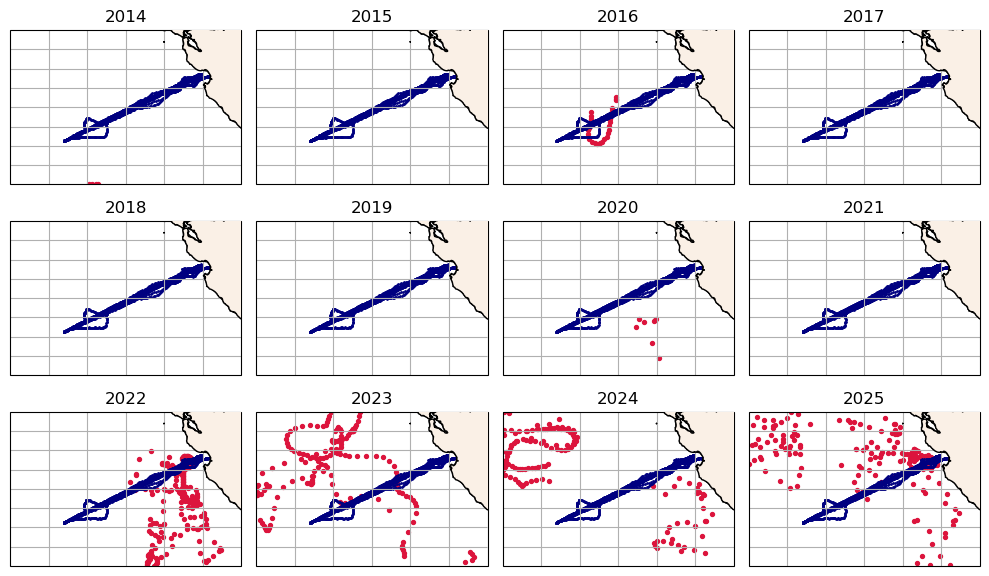

In [256]:
fig, axs = plt.subplots(3,4, figsize=(10, 6), layout='tight', subplot_kw={'projection': ccrs.PlateCarree()})
for ind, ax in enumerate(axs.flatten()):
    year = 2014 + ind
    plot_data = argoDF_valid[(argoDF_valid.year == year)].groupby('profid').first()
    mod_argo.map_study_region(ax=ax, ax_lims=box_lims) # Base plotting function that sets up matplotlib axis
    ax.scatter(plot_data.longitude, plot_data.latitude, c='crimson', s=8, transform=ccrs.PlateCarree(),
                     label='training (!=2016, 2014-2024)')
    ax.scatter(gliderINDEX.longitude, gliderINDEX.latitude, s=1, c='navy', transform=ccrs.PlateCarree(), label='glider (2020)')
    ax.set_title(year)

# 1. Data Setup

## 1.0 Argopy data import (option to skip)




The Argo data in this notebook can be downloaded using the Python package [Argopy](https://argopy.readthedocs.io/en/latest/). Argopy offers many utilities which are not covered here, but are well-documented on their website. 

To use data that has already been downloaded (recommended for demo), skip to Section 1. 

In [ ]:
from argopy import DataFetcher 
import argopy
argopy.set_options(src='erddap') # Ifremer database, updated daily

# Set to False to avoid JupyterHub crashing with multiple users.
rerun_Argopy = False
rerun_save = False

In [ ]:
# Query data around the mooring
if rerun_Argopy:
      # Format: [lon_min, lon_max, lat_min, lat_max, pres_min, pres_max, datim_min, datim_max]
      BOX = [-140, -100, 15, 55, 0, 500, '2014-01-01', '2025-12-31']
      
      # Construct an Argopy DataFetcher object to query data
      fetcher = DataFetcher(ds='bgc', mode='expert', params='all',
                        measured=['NITRATE', 'DOXY'],
                        parallel=True, progress=True,
                        chunks_maxsize={'time': 30},
                        )
      bgc_fetcher = fetcher.region(BOX).load()

      # Returns xr Dataset with point observations as dimension
      bgc_profiles = bgc_fetcher.data.argo.point2profile();
      bgc_profiles = bgc_profiles.assign_attrs(raw_attrs = '', Fetched_uri='') # simplify for save

      # Store index and domain
      bgc_index = bgc_fetcher.index
      bgc_domain = bgc_fetcher.domain 

Final post-processing of the merged dataset ...


In [ ]:
if rerun_Argopy:
    argoDF = mod_argo.create_argo_dataframe(bgc_profiles, 
                                                bgc_list = ['nitrate', 'oxygen'])
    qc_cols = ['temperature_qc', 'salinity_qc', 'pressure_qc', 'time_qc', 'position_qc', 'nitrate_qc', 'oxygen_qc'] 
    argoDF_QC = mod_argo.filter_qc_flags(argoDF, qc_vars=qc_cols, use_flags=['1', '2', '5', '8'])
    argoDF_QC = mod_argo.expand_datetime(argoDF_QC)
    argoDF_QC = mod_argo.add_mlp(argoDF_QC, threshold=0.03)

if rerun_save:
    datetag = datetime.now().strftime("%Y%m%d")
    argoDF_QC.to_csv('../cugn66_argopy_2014-2025_qc1258_acc' + datetag + '.csv')

Using flags:  ['1', '2', '5', '8']
# of profiles before QC filtering: 	 5308
# of obs before QC filtering: 		 360944 

                     1     2  5       8 nobs_dropped nobs_remaining
temperature_qc   35642     0  0  186872       138430         222514
salinity_qc      34802   750  0  185955         1007         221507
pressure_qc     221507     0  0       0            0         221507
time_qc         221409     0  0      98            0         221507
position_qc     215012     0  0    6495            0         221507
nitrate_qc      189774  3065  0     856        27812         193695
oxygen_qc       192809     0  0     757          129         193566

# of profiles after QC filtering: 	 4239



## 1.1 Exploring available data

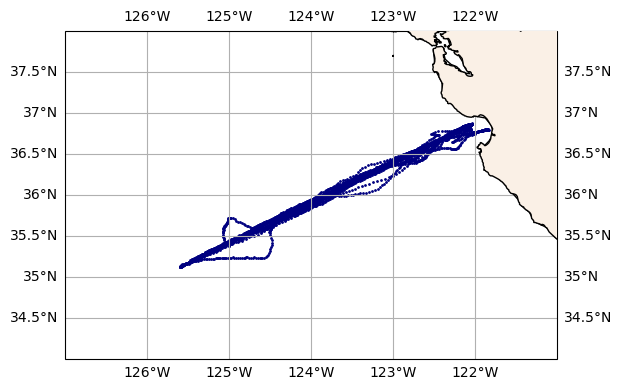

In [276]:
# First import glider data
glider_traj0 =  pd.read_csv('CUGN_line66_2022_traj0.csv', index_col=0)
gliderINDEX = glider_traj0.groupby('profile').first().dropna(subset=['temperature', 'salinity', 'oxygen'])
gliderINDEX = mod_argo.expand_datetime(gliderINDEX, 'dataframe')

ax = mod_argo.map_study_region(gridlabel=True)
ax.scatter(gliderINDEX.longitude, gliderINDEX.latitude, s=1, c='navy', transform=ccrs.PlateCarree())

To choose the spatiotemporal bounds of the Argo training data, we try to find a balance between
- data availability: how much data is available in the region(s) of interest?
- data specificity: how close are they in space/time to the intended application?


For this demo, we'll use a simple latitude/longitude box and time range 2014–2025 to query a small Argo dataset that can be used to train multiple models quickly. For a true application, prior knowledge of the study region should guide what training data to consider. Since ocean processes are nonstationary, a model should ideally include training observations close in space and time to the application.  


Total number of float profiles:  765
Time range: 	2014-01-18 to 2025-12-30
Latitude:	34.003 to 37.99695
Longitude:	-126.9924 to -121.3579


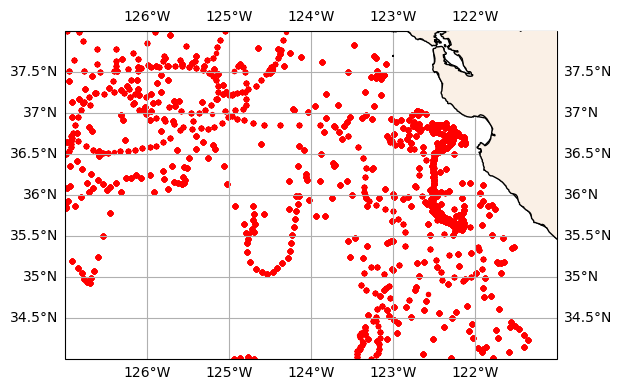

In [289]:
# Import quality-controlled argo data from Section 1.0
box_lims = [-127, -121, 34, 38]  #[lon_min, lon_max, lat_min, lat_max]
argoDF_QC = pd.read_csv('CUGN_box_argopy_qc1258_2014-2025_500dbar.csv', index_col=0)

# Initial look at the Argo data
print('Total number of float profiles: ', len(argoDF_QC.profid.unique()))
mod_argo.print_float_bounds(argoDF_QC)
ax = mod_argo.map_study_region(gridlabel=True)
sca = ax.scatter(argoDF_QC.longitude, argoDF_QC.latitude, c='r', s=8, transform=ccrs.PlateCarree())

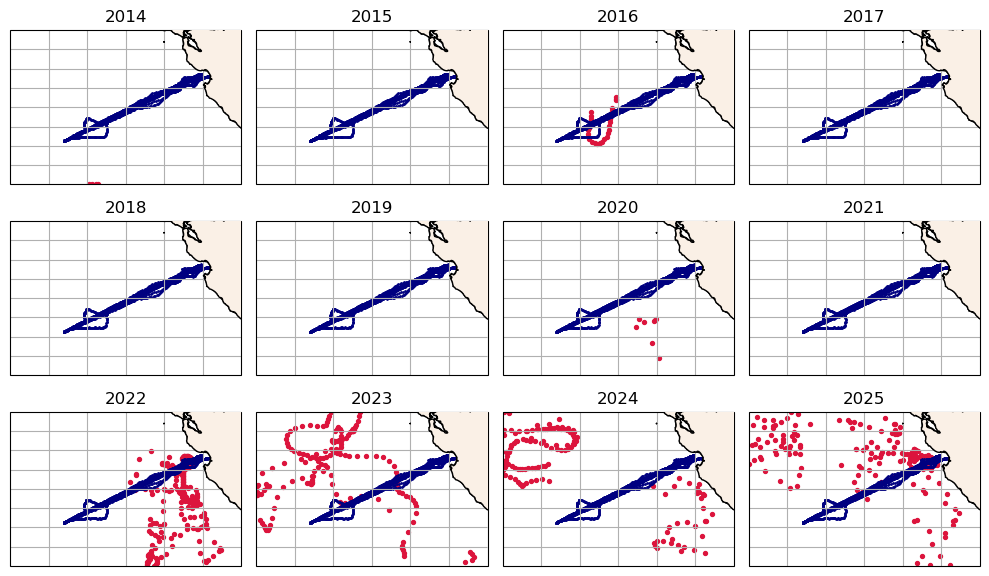

In [294]:
# Map distributions by year
fig, axs = plt.subplots(3,4, figsize=(10, 6), layout='tight', subplot_kw={'projection': ccrs.PlateCarree()})
for ind, ax in enumerate(axs.flatten()):
    year = 2014 + ind
    plot_data = argoDF_QC[(argoDF_QC.year == year)].groupby('profid').first()
    mod_argo.map_study_region(ax=ax, ax_lims=box_lims) # Base plotting function that sets up matplotlib axis
    ax.scatter(plot_data.longitude, plot_data.latitude, s=8, c='crimson', transform=ccrs.PlateCarree(), label='bgcArgo')
    ax.scatter(gliderINDEX.longitude, gliderINDEX.latitude, s=1, c='navy', transform=ccrs.PlateCarree(), label='glider (2020)')
    ax.set_title(year)

# print('wmoid count by year')
# argoINDEX = argoDF_QC.groupby('wmoid').first()
# argoINDEX.value_counts('year').sort_index()

## 1.2 Reserving test data

Independent test data should be reserved before training/validation so that we can get an independent estimate of error for the final chosen model. **The test data should not be considered at any point during model selection.** 

![Crossvalidation schematic](https://scikit-learn.org/stable/_images/grid_search_workflow.png)
Image source: scikit-learn

One way to partition test data is to group the data by time (e.g. sample random years) and reserve one group before training/validation. For this demo, we'll withhold two years, 2016 and 2024, which give us relatively good coverage of the region and represent approximately 20% of the data. 

In [295]:
withhold_test_years = [2016, 2024]
trainval_data = argoDF_valid[(~argoDF_valid.year.isin(withhold_test_years))]
test_data = argoDF_valid[argoDF_valid.year.isin(withhold_test_years)]
pc_withheld = len(test_data.profid.unique()) / len(argoDF_valid.profid.unique()) * 100
print(str(np.round(pc_withheld,1)) + '% of profiles withheld for testing')

20.7% of profiles withheld for testing


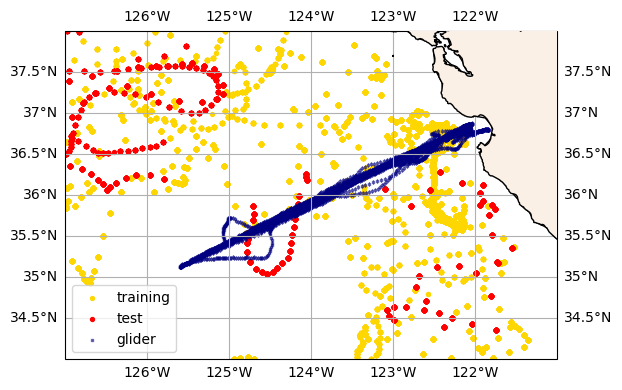

In [299]:
# Plot all data 
ax = mod_argo.map_study_region(gridlabel=True, ax_lims = box_lims) 
sca = ax.scatter(trainval_data.longitude, trainval_data.latitude, c='gold', s=8, transform=ccrs.PlateCarree(), 
                 label='training')
ax.scatter(test_data.longitude, test_data.latitude, c='red', s=8,  transform=ccrs.PlateCarree(), 
                 label='test')

ax.scatter(gliderINDEX.longitude, gliderINDEX.latitude, 
           s=2, alpha=0.5, marker='s', c='navy',
           transform=ccrs.PlateCarree(), label='glider')
ax.legend(loc='lower left', fontsize=10)

## 1.2 Splitting training/validation data


During [cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html), models are trained iteratively using a subset of the data (a "fold") and validated on the remaining withheld observations. 


![Kfold schematic](https://scikit-learn.org/stable/_images/grid_search_cross_validation.png)

We use the sklearn implementation of `KFold` as the simplest random splitter (not recommended for final CV), then introduce three other forms of splitting: 

1. by profile: shuffle the data by float profile
2. by WMO: shuffle the data by float (keep all profiles from one float together)
2. by [k-means clustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html): group the data using spatial coordinates, with optional zonal/meridional weighting


![Kmeans](https://r.geocompx.org/images/12_partitioning.png)

All three forms of splitting are called using the function `subset_folds()`, which helps organize the different types of shuffling into a consistent format. Other splitters (e.g. Leave-One-Out, GroupKFold, RepeatedKFold) can easily be added to the function. Scikit-learn has many built-in tools for splitting data that you can explore in [more detail](https://scikit-learn.org/stable/api/sklearn.model_selection.html#splitters) in your own time ([visual examples](https://scikit-learn.org/stable/auto_examples/model_selection/plot_cv_indices.html#sphx-glr-auto-examples-model-selection-plot-cv-indices-py)).


We can use a simple custom class, `CrossValContainer`, to keep track of our training and validation data for each partition of the data. 


In [308]:
# Set number of folds and initialize objects
nfolds = 5
fold_tags = ['fold' + str(i) for i in range(1, nfolds+1)]
cvtainer_bySample = (mod_argo.CrossValContainer(trainval_data, nfolds)
                                .populate_folds({'type':'random'}))

cvtainer_byPlatform = (mod_argo.CrossValContainer(trainval_data, nfolds)
                                .populate_folds({'type':'platform',
                                                'indexer':'wmoid'}))
cvtainer_byProfile = (mod_argo.CrossValContainer(trainval_data, nfolds)
                                .populate_folds({'type':'platform',
                                            'indexer':'profid'}))

### Fold Maps

The `CrossValContainer` class also has a function for quickly visualizing the training and validation splits called `.map_folds()`. Storing the plotting function in our module is a nice way to reuse plot code.

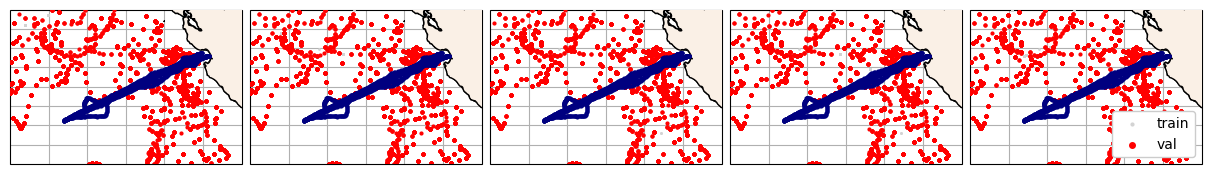

In [322]:
cvtainer_bySample.map_folds(ax_lims = box_lims, glider_data = gliderINDEX);

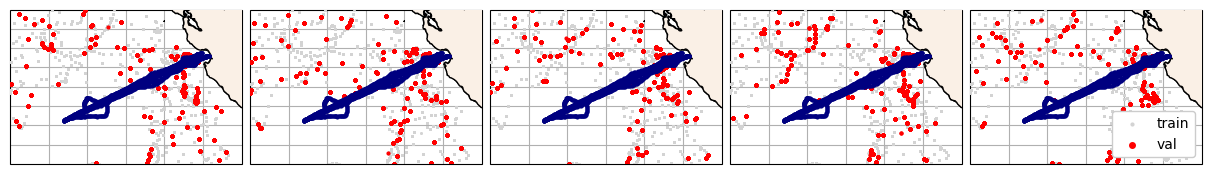

In [323]:
cvtainer_byProfile.map_folds(ax_lims = box_lims, glider_data = gliderINDEX);

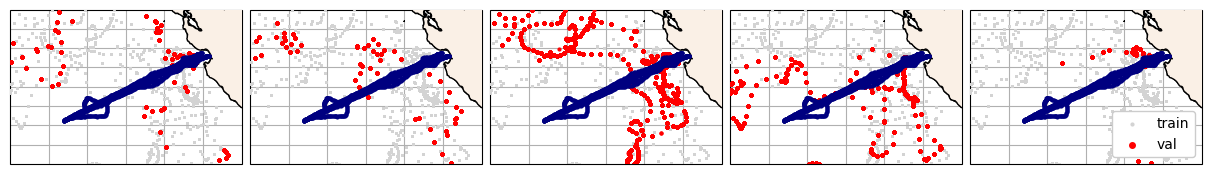

In [324]:
cvtainer_byPlatform.map_folds(ax_lims = box_lims, glider_data = gliderINDEX);

**Discussion:** comment on potential drawbacks behind each CV setup. With the same model/algorithm setup, do you expect one form of CV to return the lowest vs highest errors? 
</br></br></br></br>



**Code:** make a new CrossValContainer with k-means spatial clustering and map the folds

Hint: see .subset_folds() arguments



In [310]:
mod_argo.subset_folds?

Signature:
mod_argo.subset_folds(
    platDF,
    type='platform',
    indexer='wmoid',
    nfolds=5,
    latitude_scaler=1,
) -> list[dict[str, pandas.DataFrame]]
Docstring:
Returns dictionary of training and validation dataframes for each fold.

:param platDF: dataframe for either floatDF or shipDF
:param type: options by 'platform', 'kmeans', or 'random' 
:param indexer: choose whether to split by 'wmoid' or 'profid'
                only used if type = 'platform'
:param nfolds: (int) number of folds for cross-validation
:param latitude_scaler: float, scaling ratio for latitude/longitude in k-means
                        default of 1 gives range [-1.1] to match sinusoidal longitude range [-1,1]
                        changing to >1 gives more weight to latitude in clustering (ex: 3 yields range [-3,3])
:return: training_inds: dictionary with keys 'fold1', 'fold2', ... with training DF integer locs
         validation_inds: dictionary with keys 'fold1', 'fold2', ... with validation 

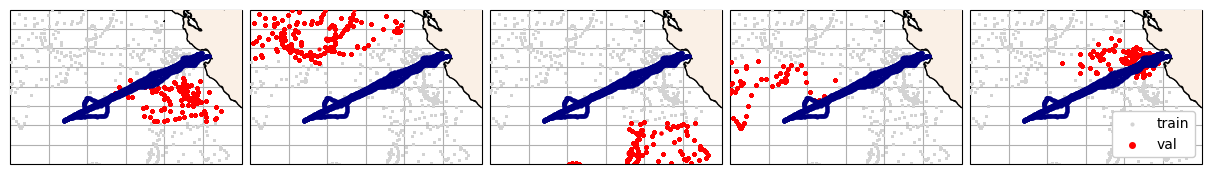

In [ ]:
# Add code here: 

# cvtainer_byKmeans = (mod_argo.CrossValContainer(trainval_data, nfolds)
#                                 .populate_folds({'type':'kmeans'}))
# cvtainer_byKmeans.map_folds(ax_lims = box_lims, glider_data = gliderINDEX);

# 2. Model training


This section highlights two aspects of regression modeling:
1. Feature lists: what input variables does the model consider for estimating the target variable?
2. Hyperparameters: what algorithm architecture leads to the best performance?

We'll also explore how the results change depending on the cross-validation setup. As we train models for each of the folds generated in the previous section, we can store results in the object `CrossValModelRun`, then write functions that act on this object to compare the errors. 


### A warning against overfitting

**Overfitting** is especially important to consider for geospatial applications! 
More flexible models can try to fit the errors (noise) on the training data too closely. Since the statistical properties of the training dataset are not fully representative, this can lead to overly optimistic validation errors when computed on in-sample data while returning poor performance on unseen data. 


This demo focuses on one algorithm, Random Forest (RF), which uses an ensemble of decision trees ("forest") to make estimates with reduced overfitting tendency ([Breiman et al. 2001](https://link.springer.com/article/10.1023/A:1010933404324)). RF incorporates randomness in two ways, by considering:
- a random subset of the data for each tree (bootstrapping)
- a random set of input features at each node of the tree


## 2.1 Comparing feature lists with K-fold CV

To determine the best feature list, we start with input variables that are known to co-vary with the target. [Feature engineering](https://geo-smart.github.io/mlgeo-book/Chapter2-DataManipulation/2.11_feature_engineering.html) can also be used to generate other relevant inputs (statistical, temporal, spatial). 

In this short demo we'll try five simple feature lists. Depending on the application, also consider incorporating atmospheric data (wind speed, sea level pressure) or satellite products (sea surface height, ocean color, sea ice).

Note on the last feature list: season is often a useful feature to include. The time of year is often encoded as two sinusoidal variables (e.g. [GOBAI-O2](https://essd.copernicus.org/articles/15/4481/2023/) in Sharp et al. 2023, [OceanSODA](https://essd.copernicus.org/articles/13/777/2021/) in Gregor et al. 2021). Another proposed alternative is the cloud-free daily maximum theoretical [solar radiation](https://pypi.org/project/solarpy/) (Song et al., in prep), which has the benefit of keeping this temporal information as a single variable. 

In [240]:
# Set feature lists to iterate over 
feat_lists = [['CT', 'SA', 'pressure'],
              ['CT', 'SA', 'oxygen', 'pressure', 'sigma0'],
              ['CT', 'SA', 'oxygen', 'pressure', 'sigma0', 'latitude', 'longitude'],
              ['CT', 'SA', 'oxygen', 'pressure', 'sigma0', 'latitude', 'longitude', 'linear_time'], # add space/time
              ['CT', 'SA', 'oxygen', 'pressure', 'sigma0', 'latitude', 'longitude', 'ydcos', 'ydsin']] # add space/season

# Set run parameters and create "run tags" for the model iterations
target_variable = 'nitrate'
use_algorithm = 'RFR'
use_hyperparams = {'n_estimators': 100,
                   'min_samples_split':10,
                   'max_features':3} # low to keep run time short

# Create a dictionary of run options (here, by feature list)
feat_options, feat_tags = mod_argo.label_run_options(feat_lists) # Converts list to dictionary

# Initialize storage dictionary
# WARNING: Comment out below if running partial:
storedRuns_bySample = {runkey:{nfold:None for nfold in fold_tags} for runkey in feat_tags}
storedRuns_byProfile = {runkey:{nfold:None for nfold in fold_tags} for runkey in feat_tags}
storedRuns_byPlatform = {runkey:{nfold:None for nfold in fold_tags} for runkey in feat_tags}

In [241]:
# Iteratively train models and store results in a CrossValModelRun object for each feat_tags
for runkey in feat_tags[:]:
    storedRuns_bySample[runkey] = mod_argo.fit_cv_model(cvtainer_bySample, target_variable,
                                                use_feats = feat_options[runkey],
                                                use_algorithm = use_algorithm,
                                                use_hyperparams = use_hyperparams)
    
    # storedRuns_byProfile[runkey] = mod_argo.fit_cv_model(cvtainer_byProfile, target_variable,
    #                                             use_feats = feat_options[runkey],
    #                                             use_algorithm = use_algorithm,
    #                                             use_hyperparams = use_hyperparams)
    


Fitting RFR...
Fitting RFR...
Fitting RFR...
Fitting RFR...
Fitting RFR...


In [242]:
# Iteratively train models and store results in a CrossValModelRun object for each feat_tags
for runkey in feat_tags[:]:
    storedRuns_byProfile[runkey] = mod_argo.fit_cv_model(cvtainer_byProfile, target_variable,
                                                use_feats = feat_options[runkey],
                                                use_algorithm = use_algorithm,
                                                use_hyperparams = use_hyperparams)

    storedRuns_byPlatform[runkey] = mod_argo.fit_cv_model(cvtainer_byPlatform, target_variable,
                                                use_feats = feat_options[runkey],
                                                use_algorithm = use_algorithm,
                                                use_hyperparams = use_hyperparams)
    


Fitting RFR...
Fitting RFR...
Fitting RFR...
Fitting RFR...
Fitting RFR...
Fitting RFR...
Fitting RFR...
Fitting RFR...
Fitting RFR...
Fitting RFR...


In [243]:
storedRuns_byKmeans = {runkey:{nfold:None for nfold in fold_tags} for runkey in feat_tags}
for runkey in feat_tags[:]:
    storedRuns_byKmeans[runkey] = mod_argo.fit_cv_model(cvtainer_byKmeans, target_variable,
                                                use_feats = feat_options[runkey],
                                                use_algorithm = use_algorithm,
                                                use_hyperparams = use_hyperparams)

Fitting RFR...
Fitting RFR...
Fitting RFR...
Fitting RFR...
Fitting RFR...


**Code:** initialize storage + run the CV with k-means spatially clustered folds

In [311]:
# Add code here: 

# storedRuns_byKmeans = ...

Since errors are stored by fold for each `CrossValModelRun` object, we can use the function `.collapse_errors()` to combine fold results into a single pandas Dataframe. 

**Code:** print the mean bias for each ModelRun (feature list) in storedRuns_byProfile (use the column 'val_error')

In [ ]:
# Add code here: 


### Linear calibration

During the `fit_cv_model()` function call, we also apply a linear calibration by fitting a line to the decile means for the estimates vs the observations. You can check the calibration coefficients (slope, intercept) as `CrossValModelRun.cal_coeffs`.

0.9870796020360054


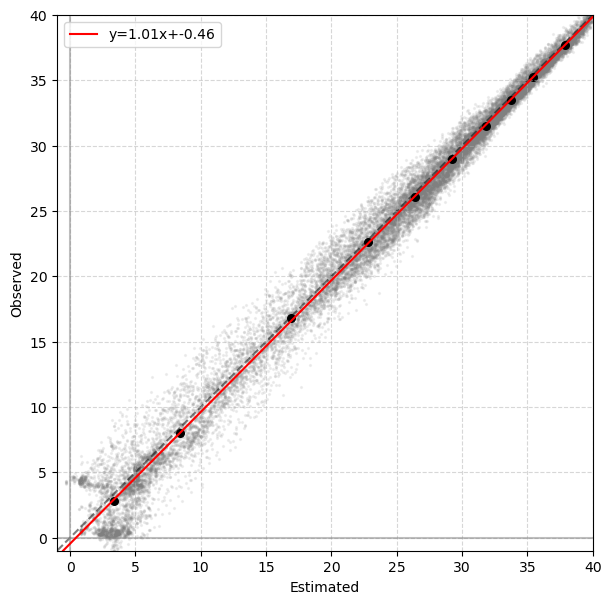

In [312]:
# Calibration plot
plot_data = storedRuns_byPlatform['featD'].collapse_errors()
mod_argo.plot_decile_calibration(plot_data.val_prediction, plot_data[target_variable], axlims=[-1,40])
print(r2_score(plot_data[target_variable], plot_data.val_prediction))


### Error Analysis

We can print a quick comparison of error metrics using the function `.storedRuns_comparison()`.

In [313]:
[print(k,v) for k,v in feat_options.items()]; print()
summary_bySample = mod_argo.storedRuns_comparison(storedRuns_bySample, error_param='lincal_error', show = True)

featA ['CT', 'SA', 'pressure']
featB ['CT', 'SA', 'oxygen', 'pressure', 'sigma0']
featC ['CT', 'SA', 'oxygen', 'pressure', 'sigma0', 'latitude', 'longitude']
featD ['CT', 'SA', 'oxygen', 'pressure', 'sigma0', 'latitude', 'longitude', 'linear_time']
featE ['CT', 'SA', 'oxygen', 'pressure', 'sigma0', 'latitude', 'longitude', 'ydcos', 'ydsin']

       median_AE   mean_AE          bias      RMSE
featA   0.414537  0.747220  4.299780e-07  1.177657
featB   0.277746  0.517352  7.950545e-07  0.835515
featC   0.218737  0.385281  2.428669e-06  0.625185
featD   0.195910  0.343291  2.702440e-06  0.559435
featE   0.200107  0.346653  3.110218e-06  0.557635


**Discussion**: Based on this CV by sample, what feature list would you use for your final model? Are the results definitive?
</br></br></br></br>

**Code:** compare results between the rest of the CV sets you ran 

In [ ]:
# Activity: compare results between the three CV sets (by sample, by profile, by k-means clustering) 

# summary_byProfile = mod_argo.storedRuns_comparison(storedRuns_byProfile, error_param='lincal_error', show = True)

       median_AE   mean_AE          bias      RMSE
featA   0.450062  0.824992 -2.753432e-06  1.297191
featB   0.301110  0.580894  1.835541e-07  0.941205
featC   0.258814  0.480988  2.187365e-06  0.788416
featD   0.237284  0.440000  2.887617e-06  0.720833
featE   0.248363  0.460450  2.766772e-06  0.746529


In [ ]:
# summary_byPlatform = mod_argo.storedRuns_comparison(storedRuns_byPlatform, error_param='lincal_error', show = True)

       median_AE   mean_AE          bias      RMSE
featA   0.740014  1.237688 -2.515506e-05  1.825485
featB   0.527778  0.920669 -1.168266e-05  1.383548
featC   0.517383  0.885839  1.895601e-06  1.310600
featD   0.500982  0.840799  3.717193e-06  1.254594
featE   0.496540  0.836574  9.489990e-07  1.240945


In [330]:
storedRuns_byPlatform['featE'].collapse_errors()

,wmoid,profid,latitude,longitude,datetime,pressure,CT,SA,sigma0,spice,...,linear_time,ydcos,ydsin,sin_longitude,cos_longitude,scaled_latitude,fold,val_prediction,val_error,val_relative_error
index,,,,,,,,,,,,,,,,,,,,,
180744,5906517,5906517_cyc030,34.09090,-121.58890,2023-05-04 01:12:57.000,7.840000,13.224784,33.313694,24.930996,0.533061,...,3410.05066,-0.515570,0.856848,-0.851828,-0.523821,-0.995373,2,2.922461,-0.578048,-0.165132
180745,5906517,5906517_cyc030,34.09090,-121.58890,2023-05-04 01:12:57.000,11.860001,13.210605,33.315531,24.935216,0.531483,...,3410.05066,-0.515570,0.856848,-0.851828,-0.523821,-0.995373,2,2.965665,-0.445128,-0.130506
180746,5906517,5906517_cyc030,34.09090,-121.58890,2023-05-04 01:12:57.000,16.859999,13.196787,33.316031,24.938339,0.528999,...,3410.05066,-0.515570,0.856848,-0.851828,-0.523821,-0.995373,2,3.119004,-0.288032,-0.084540
180747,5906517,5906517_cyc030,34.09090,-121.58890,2023-05-04 01:12:57.000,21.970000,12.834168,33.365254,25.047314,0.490888,...,3410.05066,-0.515570,0.856848,-0.851828,-0.523821,-0.995373,2,4.420359,0.249994,0.059945
180748,5906517,5906517_cyc030,34.09090,-121.58890,2023-05-04 01:12:57.000,26.970000,12.651493,33.420116,25.124820,0.494138,...,3410.05066,-0.515570,0.856848,-0.851828,-0.523821,-0.995373,2,5.450928,0.691536,0.145299
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
297035,4903026,4903026_cyc418,37.09429,-126.69664,2025-03-26 23:20:16.224,379.720000,6.911932,34.294395,26.749938,0.121663,...,4102.97241,0.104573,0.994517,-0.801811,-0.597578,-0.837273,1,36.191659,0.560666,0.015735
297036,4903026,4903026_cyc418,37.09429,-126.69664,2025-03-26 23:20:16.224,399.639980,6.589019,34.278443,26.780773,0.063278,...,4102.97241,0.104573,0.994517,-0.801811,-0.597578,-0.837273,1,37.139339,0.671257,0.018407
297037,4903026,4903026_cyc418,37.09429,-126.69664,2025-03-26 23:20:16.224,449.640000,6.088821,34.293457,26.857340,0.003609,...,4102.97241,0.104573,0.994517,-0.801811,-0.597578,-0.837273,1,38.803993,0.714533,0.018759


In [331]:
storedRuns_byPlatform['featE'].calibratedDF[['lincal_error', 'fold']].groupby('fold').mean()

,lincal_error
fold,
0,0.111972
1,-0.198439
2,-0.181220
3,0.306357
4,-0.026336


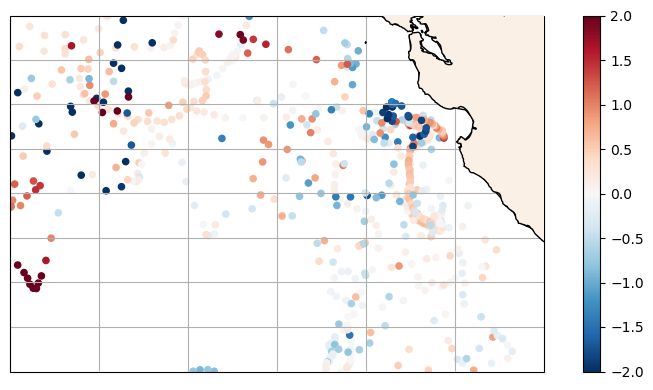

In [359]:
# Plot errors
ax = mod_argo.map_study_region() 
plot_data = storedRuns_byPlatform['featD'].average_profiles(calibrated=True)
sca = ax.scatter(plot_data.longitude, plot_data.latitude, c=plot_data.lincal_error, s=20,  
           transform=ccrs.PlateCarree(), vmin=-2, vmax=2, cmap = 'RdBu_r')
plt.colorbar(sca)

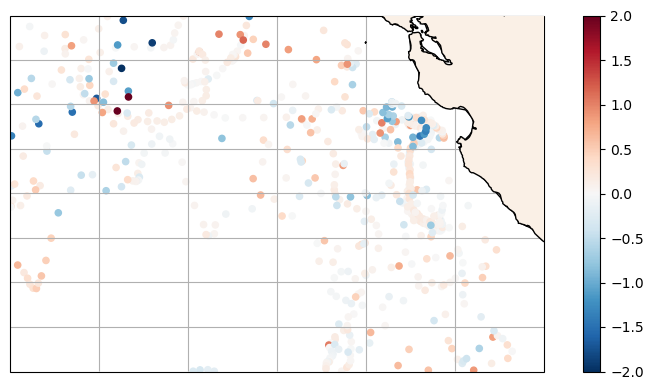

In [358]:
# Plot errors
ax = mod_argo.map_study_region() 
plot_data = storedRuns_byProfile['featD'].average_profiles(calibrated=True)
# plot_data = storedRuns_byProfile['featD'].calibratedDF[['latitude', 'longitude', 'lincal_error', 'profid']].groupby('profid').mean()
sca = ax.scatter(plot_data.longitude, plot_data.latitude, c=plot_data.lincal_error, s=20,  
           transform=ccrs.PlateCarree(), vmin=-2, vmax=2, cmap = 'RdBu_r')
plt.colorbar(sca)


In [ ]:
# summary_byKmeans = mod_argo.storedRuns_comparison(storedRuns_byKmeans, error_param='lincal_error', show = True)

       median_AE   mean_AE      bias      RMSE
featA   0.560292  1.030556 -0.000009  1.586532
featB   0.367172  0.707247 -0.000002  1.131424
featC   0.377154  0.657142  0.000007  1.016626
featD   0.365749  0.627175  0.000011  0.975427
featE   0.371621  0.647357  0.000009  1.010676


**Discussion**: How do the errors change by CV setup, why do you think this might be the case? How should one select what type(s) of data splitting to perform?
</br></br></br></br>

In [ ]:
song comment - by platform doesnt work well here with five folds because of small number


## 2.2 Exporing hyperparameters

During cross-validation, we can also tune the hyperparameters that control the machine learning architecture. This tuning is often automated using functions from sklearn (e.g. GridSearchCV, RandomSearchCV). There are also more sophisticated methods (e.g. multivariate TPE sampling) that can speed up the process when sampling a large parameter space. Some algorithms are more sensitive to hyperparameter tuning than others; Random Forest tends to offer good out-of-box performance while others like XGBoost may benefit more from tuning. 


Here, we won't perform full hyperparmeter tuning (e.g. see nested cross-validation in [Schratz et al. 2019](https://www.researchgate.net/publication/324150770_Performance_evaluation_and_hyperparameter_tuning_of_statistical_and_machine-learning_models_using_spatial_data)), but we can compare a few sets of selected hyperparameter options to highlight that these choices also affect performance.

In [ ]:
# Set hyperparameter options to iterate over 
# These are translated into a dictionary before the fit_single_fold() call
hyperparam_tags = ['maxfeat3_minsplit10_nest500', # increase number estimators
                    'maxfeat3_minsplit2_nest100', # decrease minimum samples to split
                    'maxfeat3_minsplit2_nest500'] 
hyper_options, hyper_tags = mod_argo.label_run_options(hyperparam_tags, prefix='hyper') # Converts list to dictionary

# Set run parameters and feature lists
use_feat_list = feat_options['featE']
use_cvtainer = cvtainer_byProfile

In [318]:
# Comment out if you want to store previous runs:
storedRuns_hyper = {runkey:{nfold:None for nfold in use_cvtainer.fold_list} for runkey in hyper_tags}

# Use "runkeys" as an identifier for each version of the model, here by feature list:
# Iteratively train models and store results in a CrossValModelRun object for each runkey
for runkey in hyper_tags[:]:
    use_hyperparams = mod_argo.expand_hyperparam_tag(hyper_options[runkey])
    storedRuns_hyper[runkey] = mod_argo.fit_cv_model(use_cvtainer, target_variable,
                                                use_feats = use_feat_list,
                                                use_algorithm = use_algorithm,
                                                use_hyperparams = use_hyperparams)
    

Fitting RFR...
Fitting RFR...
Fitting RFR...


**Activity:** look into the RandomForestRegressor documentation in scikit-learn. What are some ways you can increase the complexity of each individual tree? In what cases would you want weaker individual learners? 

**Discussion**: Which set of hyperparameters do you think will return the lowest validation errors?

### Error analysis

In [ ]:
summary_hyper = mod_argo.storedRuns_comparison(storedRuns_hyper, error_param='lincal_error', show = True)

# byProfile, featE   maxfeat3_minsplit10_nest100
# 0.248363  0.460450  2.766772e-06  0.746529

        median_AE   mean_AE      bias      RMSE
hyperA   0.244928  0.450415  0.000003  0.736179
hyperB   0.239911  0.441330  0.000003  0.726530
hyperC   0.236196  0.438305  0.000003  0.723100


## 2.3 Final model training and testing

Once we've selected the algorithms/features that will work best, we can take advantage of the full training/validation dataset by re-training a final model using all available observations (other than the test data).


In [222]:
final_feats = ['CT', 'SA', 'oxygen', 'pressure', 'sigma0', 'latitude', 'longitude']
final_hyperparams = {}

[finalMdl, test_errors, test_cal_coeffs] = mod_argo.fit_final_model(trainval_data, test_data, 
                                var_predict = target_variable,
                                feat_list = final_feats,
                                regressor_type = use_algorithm,
                                hyperparams = final_hyperparams)
mod_argo.summarize_errors(test_errors, error_param='lincal_error', pd_format=True)

,median_abs_error,mean_abs_error,bias,rmse
,0.331795,0.622859,-0.000118,0.948178


In [343]:
final_feats = ['CT', 'SA', 'oxygen', 'pressure', 'sigma0', 'latitude', 'longitude', 'linear_time']
final_hyperparams = {}

# test2016 = test_data[test_data.year == 2016]
[finalMdl, test_errors, test_cal_coeffs] = mod_argo.fit_final_model(trainval_data, test_data, 
                                var_predict = target_variable,
                                feat_list = final_feats,
                                regressor_type = use_algorithm,
                                hyperparams = final_hyperparams)
mod_argo.summarize_errors(test_errors, error_param='lincal_error', pd_format=True)

,median_abs_error,mean_abs_error,bias,rmse
,0.386618,0.620461,0.000024,0.907477


In [367]:
final_feats = ['CT', 'SA', 'oxygen', 'pressure', 'sigma0', 'latitude', 'longitude', 'ydcos', 'ydsin']
final_hyperparams = {}

[finalMdl, test_errors, test_cal_coeffs] = mod_argo.fit_final_model(trainval_data, test_data, 
                                var_predict = target_variable,
                                feat_list = final_feats,
                                regressor_type = use_algorithm,
                                hyperparams = final_hyperparams)
mod_argo.summarize_errors(test_errors, error_param='lincal_error', pd_format=True)

,median_abs_error,mean_abs_error,bias,rmse
,0.366327,0.601256,0.00002,0.92091


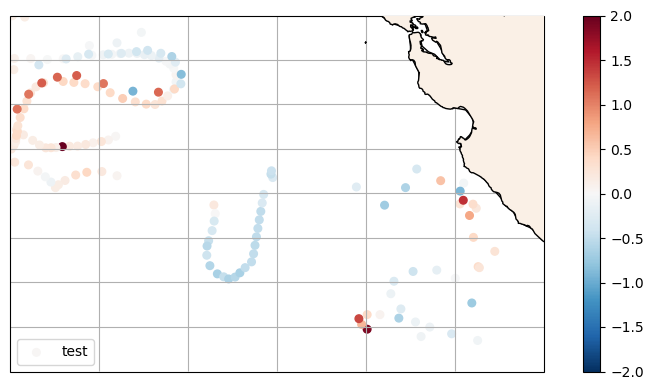

In [368]:
# Plot errors
ax = mod_argo.map_study_region() 
plot_data = test_errors.groupby('profid')[['latitude', 'longitude', 'lincal_error']].mean()
sca = ax.scatter(plot_data.longitude, plot_data.latitude, c=plot_data.lincal_error, s=30,  
           transform=ccrs.PlateCarree(), label='test', vmin=-2, vmax=2, cmap = 'RdBu_r')
plt.colorbar(sca)
ax.legend(loc='lower left', fontsize=10)

Note that the CV shuffled by sample would have given an overly optimistic estimate of error. 

# 3. Application to glider data

To save time, the features have already been calculated for the glider data. We can run the final model:

In [ ]:
glider_traj0

In [373]:
glider_preds = mod_argo.apply_final_model(glider_traj0, 
                                          final_feats, finalMdl, test_cal_coeffs)

In [374]:
glider_preds.rename(columns={'prediction': 'nitrate_pred'}, inplace=True)

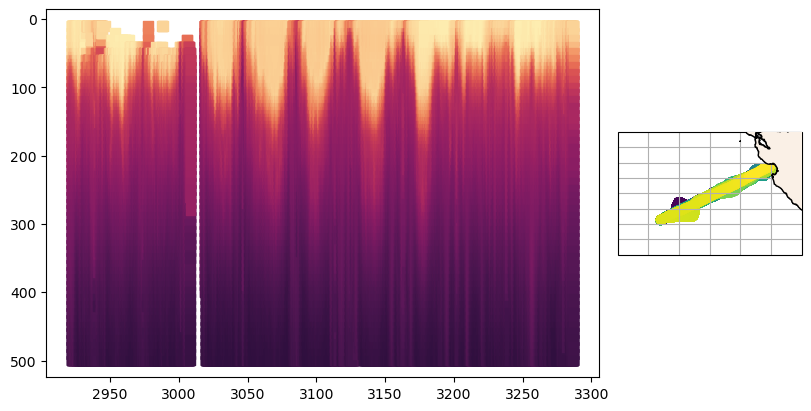

In [379]:
#Visualize
fig = plt.figure(figsize=(8, 4), layout='constrained')
gs = fig.add_gridspec(1,2, width_ratios=[3, 1])
ax1 = fig.add_subplot(gs[0,:1])
ax2 = fig.add_subplot(gs[1:], projection=ccrs.PlateCarree())
axs = [ax1, ax2]
for ax in axs[:1]:
    plot_data = glider_preds.reset_index()
    # plot_data = plot_data[(plot_data.datetime >  '2022-08-01') & (plot_data.datetime < '2022-08-13')] 
    ax.scatter(plot_data.linear_time, plot_data.depth, c=plot_data.nitrate_pred, cmap=cmo.matter, s=50, marker='s')
    # ax.set_ylim([0, 100])
    ax.invert_yaxis()

for ax in axs[1:]:
    mod_argo.map_study_region(ax=ax, ax_lims=box_lims)
    ax.scatter(plot_data.longitude, plot_data.latitude, c=plot_data.linear_time)

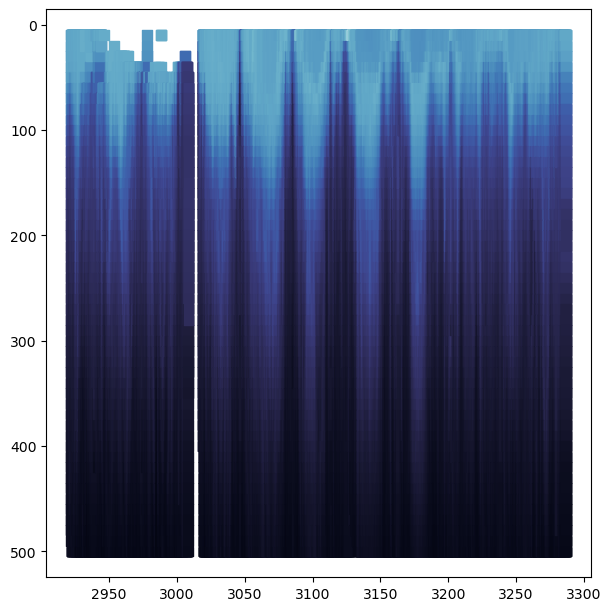

In [385]:
fig = plt.figure(figsize=(6,6), layout='constrained')
ax = fig.gca()
ax.scatter(plot_data.linear_time, plot_data.depth, c=plot_data.oxygen, cmap=cmo.ice, s=50, marker='s')
# ax.set_ylim([0, 100])
ax.invert_yaxis()

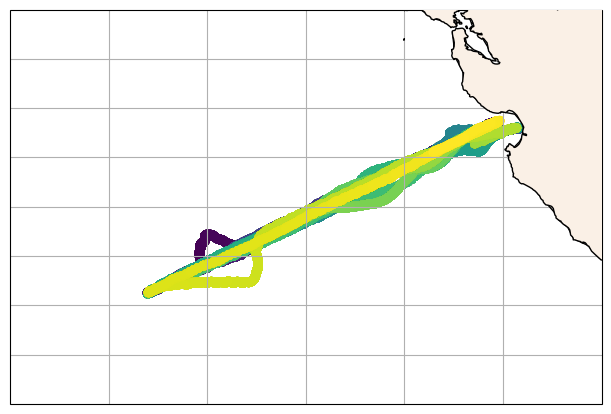

In [381]:
fig = plt.figure(figsize=(6,6), layout='constrained')
ax = fig.add_subplot(111, projection=ccrs.PlateCarree())
mod_argo.map_study_region(ax=ax, ax_lims=box_lims)
ax.scatter(plot_data.longitude, plot_data.latitude, c=plot_data.linear_time)